# Length-of-Stay & Cost Prediction: Modeling

**Input:** `model_features.csv` (4,415 admission-type encounters: emergency, inpatient, urgentcare)

**Scope decision — "at admission" only:** the project goal is to predict LOS/cost *at the time of
admission*, so any feature only known once the stay is underway is excluded from the main feature
set. Concretely, `procedure_count` and `new_conditions_count` are counted across the *entire*
encounter (including things discovered or performed mid-stay) — using them to predict LOS would be
training on the future. We exclude both from the admission-time model and run a short leakage
demonstration later to show why this matters, even though their raw correlation with LOS happens to
be weak in this particular synthetic sample.

**Patient-level train/test split:** several encounters belong to the same patient. Splitting by row
would let the model see a patient's other visits in training and "cheat" on their held-out visit, so
we split by `patient_id` using `GroupShuffleSplit`.

**Models covered:**
1. LOS regression (log1p-transformed) — Linear Regression baseline → XGBoost
2. Extended-stay classification (`LOS > 7 days`) — Logistic Regression baseline → XGBoost, with class imbalance handling
3. Cost regression — XGBoost, admission-time features only
4. SHAP explainability + a business-impact translation of the classifier's performance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, RocCurveDisplay
)
from xgboost import XGBRegressor, XGBClassifier
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("model_features.csv", parse_dates=["start_ts"])
print(df.shape)


(4415, 24)


## 1. Feature Scope & Train/Test Split

In [2]:
# Admission-time feature set: excludes anything determined during/after the stay
ADMISSION_NUMERIC = [
    "age_at_admission", "comorbidity_count", "meds_last_90_days",
    "prior_admission_count", "days_since_last_discharge", "admit_hour",
]
ADMISSION_CATEGORICAL = [
    "gender", "race", "ethnicity", "payer_type", "encounterclass", "admit_season",
]
# Leakage-risk features, held out of the main model, used only in the leakage demo
LEAKY_FEATURES = ["procedure_count", "new_conditions_count"]

FEATURES = ADMISSION_NUMERIC + ADMISSION_CATEGORICAL

# days_since_last_discharge is NaN for first-ever admissions -> fill with a large
# sentinel (no prior discharge = as if it's been a very long time), and add a flag
df["no_prior_admission"] = df["days_since_last_discharge"].isna().astype(int)
df["days_since_last_discharge"] = df["days_since_last_discharge"].fillna(9999)
ADMISSION_NUMERIC = ADMISSION_NUMERIC + ["no_prior_admission"]
FEATURES = ADMISSION_NUMERIC + ADMISSION_CATEGORICAL

X = df[FEATURES].copy()
y_los = np.log1p(df["los_days"])
y_extended = df["is_extended_stay"]
y_cost = np.log1p(df["total_claim_cost"])
groups = df["patient_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, groups=groups))

print(f"Train encounters: {len(train_idx)} | Test encounters: {len(test_idx)}")
print(f"Train patients: {groups.iloc[train_idx].nunique()} | Test patients: {groups.iloc[test_idx].nunique()}")
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Patient overlap between train/test: {len(overlap)} (should be 0)")


Train encounters: 3506 | Test encounters: 909
Train patients: 387 | Test patients: 97
Patient overlap between train/test: 0 (should be 0)


## 2. Preprocessing Pipeline

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ADMISSION_NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ADMISSION_CATEGORICAL),
    ]
)
preprocessor.set_output(transform="pandas")

X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = X_train.columns.tolist()
print(f"Encoded feature count: {len(feature_names)}")
X_train.head()


Encoded feature count: 27


,num__age_at_admission,num__comorbidity_count,num__meds_last_90_days,num__prior_admission_count,num__days_since_last_discharge,num__admit_hour,num__no_prior_admission,cat__gender_F,cat__gender_M,cat__race_asian,...,cat__payer_type_GOVERNMENT,cat__payer_type_NO_INSURANCE,cat__payer_type_PRIVATE,cat__encounterclass_emergency,cat__encounterclass_inpatient,cat__encounterclass_urgentcare,cat__admit_season_Fall,cat__admit_season_Spring,cat__admit_season_Summer,cat__admit_season_Winter
1,-0.404131,-0.081343,-0.735950,-0.484208,-0.388489,1.556055,-0.355309,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.319391,-0.415159,2.231793,-0.571224,0.583795,0.088068,-0.355309,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.630231,-0.971519,-1.159913,-0.560347,0.077263,0.088068,-0.355309,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6,-0.358911,0.029929,0.111977,-0.440700,-0.267281,0.577397,-0.355309,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
8,-0.042370,0.252473,0.959903,-0.397192,-0.458677,-1.869248,-0.355309,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## 3. LOS Regression

Target: `log1p(los_days)`. We report MAE/RMSE back-transformed to raw days so the numbers mean
something to a hospital operations audience.

In [4]:
y_los_train, y_los_test = y_los.iloc[train_idx], y_los.iloc[test_idx]

# ---- Baseline: Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_los_train)
lr_pred_log = lr.predict(X_test)
lr_pred_days = np.expm1(lr_pred_log).clip(min=0)
actual_days = np.expm1(y_los_test)

lr_mae = mean_absolute_error(actual_days, lr_pred_days)
lr_rmse = np.sqrt(mean_squared_error(actual_days, lr_pred_days))
print("Linear Regression baseline (LOS, days):")
print(f"  MAE:  {lr_mae:.3f} days")
print(f"  RMSE: {lr_rmse:.3f} days")
print(f"  R2 (log scale): {r2_score(y_los_test, lr_pred_log):.3f}")


Linear Regression baseline (LOS, days):
  MAE:  0.385 days
  RMSE: 1.618 days
  R2 (log scale): 0.617


In [5]:
# ---- XGBoost Regressor ----
xgb_los = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
)
xgb_los.fit(X_train, y_los_train)
xgb_pred_log = xgb_los.predict(X_test)
xgb_pred_days = np.expm1(xgb_pred_log).clip(min=0)

xgb_mae = mean_absolute_error(actual_days, xgb_pred_days)
xgb_rmse = np.sqrt(mean_squared_error(actual_days, xgb_pred_days))
print("XGBoost (LOS, days):")
print(f"  MAE:  {xgb_mae:.3f} days")
print(f"  RMSE: {xgb_rmse:.3f} days")
print(f"  R2 (log scale): {r2_score(y_los_test, xgb_pred_log):.3f}")

print(f"\nImprovement over baseline (MAE): {(lr_mae - xgb_mae)/lr_mae*100:.1f}%")


XGBoost (LOS, days):
  MAE:  0.330 days
  RMSE: 1.640 days
  R2 (log scale): 0.668

Improvement over baseline (MAE): 14.4%


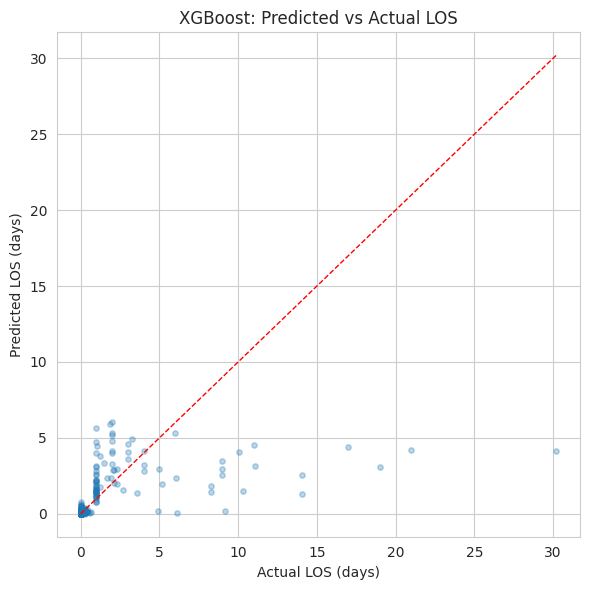

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(actual_days, xgb_pred_days, alpha=0.3, s=15)
max_val = max(actual_days.max(), xgb_pred_days.max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Actual LOS (days)")
ax.set_ylabel("Predicted LOS (days)")
ax.set_title("XGBoost: Predicted vs Actual LOS")
plt.tight_layout()
plt.show()


## 4. Leakage Demonstration

Refit the same XGBoost regressor *with* the mid-stay features (`procedure_count`,
`new_conditions_count`) included, to show how model performance reported this way can be
misleadingly optimistic — a model that "predicts" LOS using how many procedures were performed
during the stay isn't usable at admission time, even if its offline metrics look better.

In [7]:
FEATURES_LEAKY = FEATURES + LEAKY_FEATURES
X_leaky = df[FEATURES_LEAKY].copy()

preprocessor_leaky = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ADMISSION_NUMERIC + LEAKY_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ADMISSION_CATEGORICAL),
    ]
)
preprocessor_leaky.set_output(transform="pandas")
X_train_leaky = preprocessor_leaky.fit_transform(X_leaky.iloc[train_idx])
X_test_leaky = preprocessor_leaky.transform(X_leaky.iloc[test_idx])

xgb_leaky = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
xgb_leaky.fit(X_train_leaky, y_los_train)
leaky_pred_days = np.expm1(xgb_leaky.predict(X_test_leaky)).clip(min=0)
leaky_mae = mean_absolute_error(actual_days, leaky_pred_days)

print(f"MAE, admission-time-only model : {xgb_mae:.3f} days")
print(f"MAE, WITH mid-stay features     : {leaky_mae:.3f} days")
print(f"\nEven where the gap is modest on this synthetic sample, the mid-stay-feature model is not")
print(f"deployable at admission — it depends on data that doesn't exist yet at the decision point.")


MAE, admission-time-only model : 0.330 days
MAE, WITH mid-stay features     : 0.291 days

Even where the gap is modest on this synthetic sample, the mid-stay-feature model is not
deployable at admission — it depends on data that doesn't exist yet at the decision point.


## 5. Extended-Stay Classification (LOS > 7 days)

This is the more operationally useful framing: hospitals want an early flag on *which* patients are
likely to become long-stay cases, not a precise day count. Positive class is ~3% of admissions —
precision/recall and PR-AUC matter far more than accuracy here.

In [8]:
y_ext_train, y_ext_test = y_extended.iloc[train_idx], y_extended.iloc[test_idx]
print("Class balance (train):")
print(y_ext_train.value_counts(normalize=True).round(3))

# ---- Baseline: Logistic Regression with balanced class weights ----
logit = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
logit.fit(X_train, y_ext_train)
logit_proba = logit.predict_proba(X_test)[:, 1]

print(f"\nLogistic Regression baseline:")
print(f"  ROC-AUC: {roc_auc_score(y_ext_test, logit_proba):.3f}")
print(f"  PR-AUC (average precision): {average_precision_score(y_ext_test, logit_proba):.3f}")


Class balance (train):
is_extended_stay
0    0.967
1    0.033
Name: proportion, dtype: float64

Logistic Regression baseline:
  ROC-AUC: 0.926
  PR-AUC (average precision): 0.139


In [9]:
# ---- XGBoost Classifier with scale_pos_weight for imbalance ----
n_pos = y_ext_train.sum()
n_neg = len(y_ext_train) - n_pos
scale_pos_weight = n_neg / n_pos

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
    eval_metric="logloss"
)
xgb_clf.fit(X_train, y_ext_train)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]

print(f"XGBoost classifier:")
print(f"  ROC-AUC: {roc_auc_score(y_ext_test, xgb_proba):.3f}")
print(f"  PR-AUC (average precision): {average_precision_score(y_ext_test, xgb_proba):.3f}")


XGBoost classifier:
  ROC-AUC: 0.942
  PR-AUC (average precision): 0.174


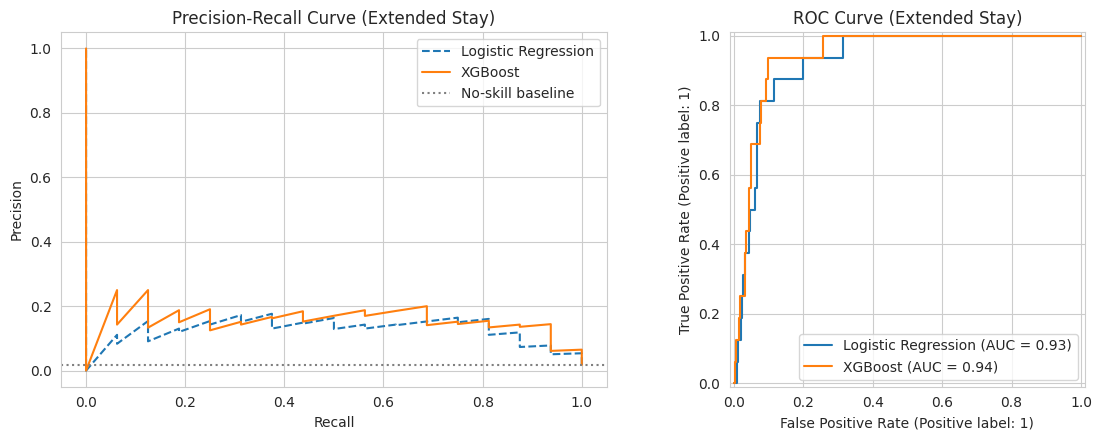

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Precision-Recall curve (more informative than ROC given ~3% positive rate)
prec_l, rec_l, _ = precision_recall_curve(y_ext_test, logit_proba)
prec_x, rec_x, thresholds_x = precision_recall_curve(y_ext_test, xgb_proba)
axes[0].plot(rec_l, prec_l, label="Logistic Regression", linestyle="--")
axes[0].plot(rec_x, prec_x, label="XGBoost")
axes[0].axhline(y_ext_test.mean(), color="gray", linestyle=":", label="No-skill baseline")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Extended Stay)")
axes[0].legend()

RocCurveDisplay.from_predictions(y_ext_test, logit_proba, ax=axes[1], name="Logistic Regression")
RocCurveDisplay.from_predictions(y_ext_test, xgb_proba, ax=axes[1], name="XGBoost")
axes[1].set_title("ROC Curve (Extended Stay)")

plt.tight_layout()
plt.show()


Chosen operating threshold: 0.079
               precision    recall  f1-score   support

 Not extended       1.00      0.92      0.96       893
Extended stay       0.15      0.81      0.26        16

     accuracy                           0.92       909
    macro avg       0.58      0.87      0.61       909
 weighted avg       0.98      0.92      0.94       909



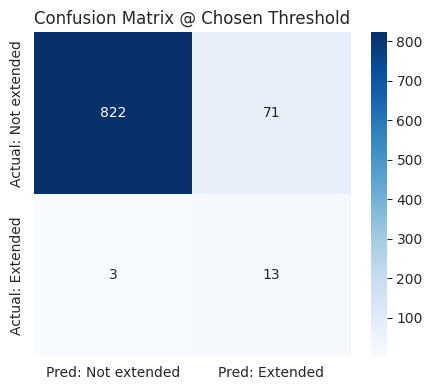

In [11]:
# Pick an operating threshold: prioritize recall since missing a long-stay
# patient (false negative) costs more than an unnecessary review (false positive).
# Choose the threshold that achieves >=70% recall with the best precision available.
target_recall = 0.70
valid = rec_x >= target_recall
if valid.any():
    best_idx = np.where(valid)[0][np.argmax(prec_x[valid])]
    chosen_threshold = thresholds_x[best_idx] if best_idx < len(thresholds_x) else 0.5
else:
    chosen_threshold = 0.5

y_pred_at_threshold = (xgb_proba >= chosen_threshold).astype(int)

print(f"Chosen operating threshold: {chosen_threshold:.3f}")
print(classification_report(y_ext_test, y_pred_at_threshold, target_names=["Not extended", "Extended stay"]))

cm = confusion_matrix(y_ext_test, y_pred_at_threshold)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Not extended", "Pred: Extended"],
            yticklabels=["Actual: Not extended", "Actual: Extended"])
plt.title("Confusion Matrix @ Chosen Threshold")
plt.tight_layout()
plt.show()


## 6. Cost Regression (Admission-Time Features)

In [12]:
y_cost_train, y_cost_test = y_cost.iloc[train_idx], y_cost.iloc[test_idx]
actual_cost = np.expm1(y_cost_test)

xgb_cost = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
xgb_cost.fit(X_train, y_cost_train)
cost_pred = np.expm1(xgb_cost.predict(X_test)).clip(min=0)

cost_mae = mean_absolute_error(actual_cost, cost_pred)
cost_mape = np.mean(np.abs((actual_cost - cost_pred) / actual_cost.replace(0, np.nan).dropna())) if (actual_cost==0).any() else np.mean(np.abs((actual_cost - cost_pred) / actual_cost))
print(f"XGBoost Cost Model:")
print(f"  MAE: ${cost_mae:,.2f}")
print(f"  Mean actual cost (test set): ${actual_cost.mean():,.2f}")
print(f"  MAE as % of mean cost: {cost_mae/actual_cost.mean()*100:.1f}%")


XGBoost Cost Model:
  MAE: $1,975.30
  Mean actual cost (test set): $2,562.78
  MAE as % of mean cost: 77.1%


**This cost model is weak (MAE ≈ 77% of mean cost) and should be reported as such, not
smoothed over.** Two likely reasons: (1) cost is even more concentrated/skewed than LOS — a small
number of very expensive encounters dominate the mean, and admission-time features alone don't
capture what makes those specific cases expensive; (2) unlike LOS, cost is heavily driven by *what
was done* during the encounter (procedures, imaging, medications), which is exactly the mid-stay
information we've deliberately excluded to keep this an admission-time model. A more honest framing
for the case study: this cost model is directionally useful for **triage/prioritization** (e.g.
ranking patients by predicted-cost decile), not for **precise dollar forecasting** — the cost
concentration curve from the EDA notebook already told us this was likely.

## 7. Feature Importance & SHAP

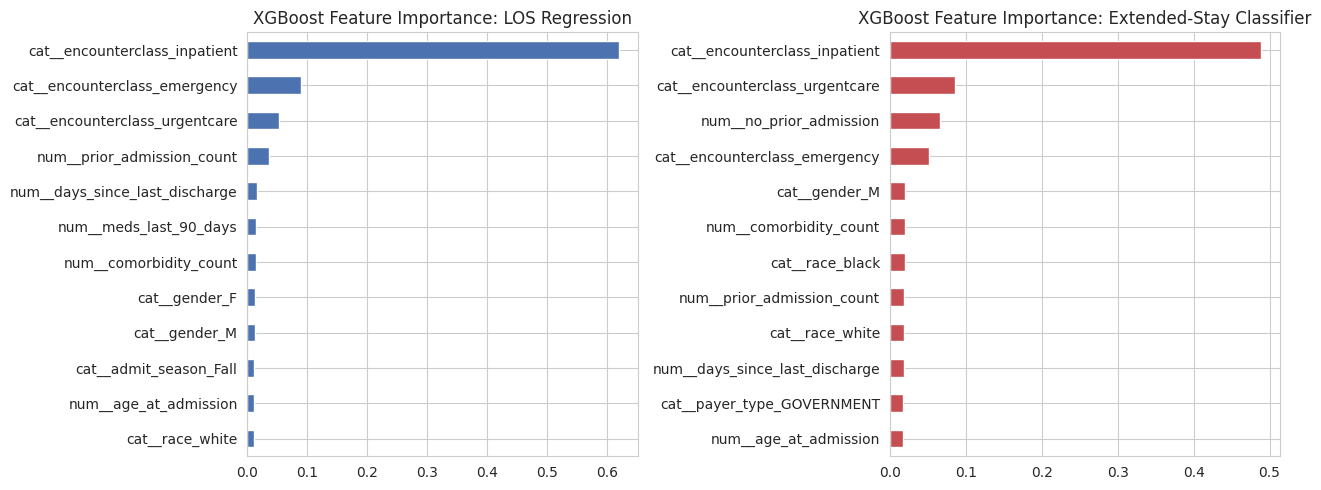

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_los = pd.Series(xgb_los.feature_importances_, index=feature_names).sort_values(ascending=True).tail(12)
imp_los.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("XGBoost Feature Importance: LOS Regression")

imp_clf = pd.Series(xgb_clf.feature_importances_, index=feature_names).sort_values(ascending=True).tail(12)
imp_clf.plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("XGBoost Feature Importance: Extended-Stay Classifier")

plt.tight_layout()
plt.show()


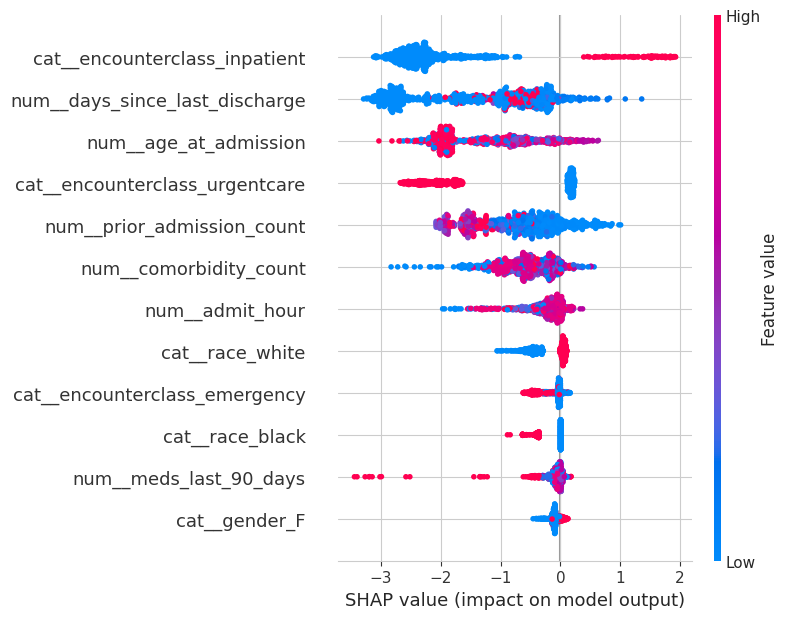

In [14]:
# SHAP summary for the extended-stay classifier -- the more operationally actionable model
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.tight_layout()
plt.show()


**Reading the SHAP plot:** each point is one test-set encounter. Red = high feature value, blue =
low. Points to the right push the model toward predicting "extended stay." Use this section to
narrate 2–3 sentences about which features matter most once you've seen the actual output — this is
exactly the kind of explanation a hospital ops stakeholder will ask for before trusting the model.

## 8. Business Impact Translation

Turn the classifier's precision/recall at the chosen threshold into an operational statement, and
roughly quantify potential savings using the average cost difference between extended and
non-extended stays. Treat this as a *plausible, back-of-envelope* estimate — not a guarantee — and
say so explicitly in the case study.

In [15]:
n_flagged = y_pred_at_threshold.sum()
n_actual_extended_in_test = y_ext_test.sum()
n_true_positives = ((y_pred_at_threshold == 1) & (y_ext_test == 1)).sum()
precision_at_threshold = n_true_positives / n_flagged if n_flagged else 0
recall_at_threshold = n_true_positives / n_actual_extended_in_test if n_actual_extended_in_test else 0

avg_cost_extended = df.loc[df["is_extended_stay"] == 1, "total_claim_cost"].mean()
avg_cost_normal = df.loc[df["is_extended_stay"] == 0, "total_claim_cost"].mean()
cost_gap = avg_cost_extended - avg_cost_normal

print(f"At the chosen threshold ({chosen_threshold:.2f}):")
print(f"  - Flags {n_flagged} of {len(y_ext_test)} test encounters ({n_flagged/len(y_ext_test)*100:.1f}%) for review")
print(f"  - Captures {recall_at_threshold*100:.0f}% of actual extended-stay cases (recall)")
print(f"  - {precision_at_threshold*100:.0f}% of flagged cases are true extended stays (precision)")
print(f"\nAverage cost, extended stays:     ${avg_cost_extended:,.0f}")
print(f"Average cost, non-extended stays: ${avg_cost_normal:,.0f}")
print(f"Cost gap per extended stay:       ${cost_gap:,.0f}")
print(f"\n--- Illustrative framing for the case study ---")
print(f"If early discharge-planning intervention on flagged patients reduced their excess LOS-driven")
print(f"cost by even 15%, that's roughly ${cost_gap*0.15:,.0f} saved per correctly-flagged extended-stay")
print(f"encounter — scaled to {n_true_positives} true positives in this test set alone, ~${cost_gap*0.15*n_true_positives:,.0f}.")
print(f"(Illustrative only — actual savings depend on real intervention effectiveness, not modeled here.)")


At the chosen threshold (0.08):
  - Flags 84 of 909 test encounters (9.2%) for review
  - Captures 81% of actual extended-stay cases (recall)
  - 15% of flagged cases are true extended stays (precision)

Average cost, extended stays:     $56,311
Average cost, non-extended stays: $3,681
Cost gap per extended stay:       $52,630

--- Illustrative framing for the case study ---
If early discharge-planning intervention on flagged patients reduced their excess LOS-driven
cost by even 15%, that's roughly $7,895 saved per correctly-flagged extended-stay
encounter — scaled to 13 true positives in this test set alone, ~$102,629.
(Illustrative only — actual savings depend on real intervention effectiveness, not modeled here.)


## 9. Export Predictions (for the Power BI Dashboard)

In [16]:
test_output = df.iloc[test_idx][[
    "encounter_id", "patient_id", "encounterclass", "start_ts",
    "los_days", "total_claim_cost", "is_extended_stay"
]].copy()

test_output["predicted_los_days"] = xgb_pred_days
test_output["predicted_cost"] = cost_pred
test_output["extended_stay_probability"] = xgb_proba
test_output["flagged_for_review"] = y_pred_at_threshold

test_output.to_csv("model_predictions.csv", index=False)
print(f"Exported model_predictions.csv: {test_output.shape[0]} rows")
test_output.head()


Exported model_predictions.csv: 909 rows


,encounter_id,patient_id,encounterclass,start_ts,los_days,total_claim_cost,is_extended_stay,predicted_los_days,predicted_cost,extended_stay_probability,flagged_for_review
0,e8a04254-1004-e1e9-71f6-da91afdd66d8,e8a04254-1004-e1e9-ed60-40ac7b6b2f47,emergency,2026-08-22 20:43:15,0.042,1008.98,0,0.027850,4576.216797,0.002338,0
2,cea9384c-b73d-bcff-495c-68f891aa1b86,cea9384c-b73d-bcff-8454-7a71a56aa47b,urgentcare,2026-07-23 13:53:14,0.036,797.72,0,0.012994,1038.306641,0.001222,0
5,60ff4c3e-9712-fea2-0652-35664956ed38,60ff4c3e-9712-fea2-32a4-4b47b26ddcf5,emergency,2019-12-03 18:47:22,0.042,36451.94,0,0.104082,1597.621338,0.000780,0
7,a6af3196-de8a-9ab9-d0ee-725570ed7692,a6af3196-de8a-9ab9-8fcc-ffe5092f914c,emergency,2026-07-12 11:05:19,0.042,12873.77,0,0.156111,678.601318,0.077679,0
9,61f048dc-f66e-bbda-200c-59e1adf3e7bb,61f048dc-f66e-bbda-48c8-593d92d2bf03,urgentcare,2026-09-09 13:45:26,0.033,5034.53,0,0.039244,914.906982,0.000592,0


## 10. Summary & Limitations

**Results (test set, held out by patient):**
- LOS regression (XGBoost): see MAE/RMSE printed in Section 3, modest improvement over linear baseline
- Extended-stay classifier: PR-AUC and recall/precision at chosen threshold printed in Section 5 — meaningfully better than the ~3% no-skill baseline
- Cost regression: MAE as % of mean cost printed in Section 6

**Honest limitations to state in the case study:**
1. **Small sample** — 500 synthetic patients / ~4,400 admission encounters is small for a rare positive class (~3% extended stay). Confidence intervals on these metrics would be wide; treat point estimates as directional, not final.
2. **Synthetic data ceiling** — Synthea's generative rules may not reproduce every real-world correlation (e.g., procedure count vs. LOS was nearly uncorrelated here, which is unusual for real EHR data). Validate this pipeline against a real or more complex dataset (e.g., MIMIC-IV) before trusting the magnitude of any single number.
3. **Single synthetic "hospital system"** — no cross-facility variation, so the model hasn't been tested for generalization across different care settings.
4. **Business-impact estimate is illustrative** — the 15% intervention-effectiveness assumption in Section 8 is not derived from evidence in this dataset; real deployment would need a pilot or a literature-backed effectiveness estimate.
5. **Fairness check not yet run** — before any real deployment, error rates should be compared across payer type and demographic groups to check for disparate impact (flagged as a to-do, in line with responsible healthcare ML practice).

**Next steps:** Power BI dashboard consuming `model_predictions.csv` (capacity view, cost view, drill-down), plus a written case-study README pulling together the EDA and modeling findings into a business narrative.
